# Baseline VLP model

This notebook is a simple end-to-end starter baseline for Task 1. It trains only on `data/train_clean_3x3_1cm.csv` and evaluates on the provided `data/validation_clean_3x3_1cm.csv`.

The notebook demonstrates:

1. loading the fixed cleaned 3x3 training and validation CSVs;
2. scaling RSS values and coordinate targets;
3. training a small MLP;
4. reporting positioning error in centimeters;
5. exporting the trained model to a `.tflite` flatbuffer with LiteRT Torch;
6. checking the TFLite model on the host;
7. exporting the same flatbuffer and scaling constants into the Pico firmware template.


In [2]:
from pathlib import Path
import csv
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from vlp_hackathon.baseline_model import BaselineMLP
from vlp_hackathon.export import tflite_to_c_array
from vlp_hackathon.metrics import euclidean_errors_cm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("PyTorch:", torch.__version__)

# Make sure to run on CPU
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''

PyTorch: 2.11.0+cu130


## Load the fixed Task 1 train and validation CSVs

Task 1 data are already reduced to Configuration 2. Each CSV contains `x`, `y`, and these nine RSS channels:

```text
[0, 2, 4,
 12, 14, 16,
 24, 26, 28]
```

Coordinates are stored in millimeters and converted to centimeters. The raw 6x6 development dataset is not used for training this baseline.


In [3]:
TRAIN_CSV = ROOT / "data" / "train_clean_3x3_1cm.csv"
VALIDATION_CSV = ROOT / "data" / "validation_clean_3x3_1cm.csv"
CONF1_COLUMNS = ["led_0", "led_1", "led_2", "led_3", "led_4", "led_5",
                 "led_6", "led_7", "led_8", "led_9", "led_10", "led_11",
                 "led_12", "led_13", "led_14", "led_15", "led_16", "led_17",
                 "led_18", "led_19", "led_20", "led_21", "led_22", "led_23",
                 "led_24", "led_25", "led_26", "led_27", "led_28", "led_29",
                 "led_30", "led_31", "led_32", "led_33", "led_34", "led_35"]
CONF2_COLUMNS = ["led_0", "led_2", "led_4", "led_12", "led_14", "led_16", "led_24", "led_26", "led_28"]

def load_task1_csv(path):
    rows = []
    with path.open(newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            rows.append([float(row["x"]), float(row["y"]), *[float(row[c]) for c in CONF2_COLUMNS]])
    arr = np.asarray(rows, dtype=np.float32)
    return arr[:, 2:], arr[:, :2] / 10.0

X_train_raw, y_train_cm = load_task1_csv(TRAIN_CSV)
X_val_raw, y_val_cm = load_task1_csv(VALIDATION_CSV)

print("Training rows:", len(X_train_raw))
print("Validation rows:", len(X_val_raw))
print("Input shape:", X_train_raw.shape)
print("Target x range (cm):", y_train_cm[:, 0].min(), "to", y_train_cm[:, 0].max())
print("Target y range (cm):", y_train_cm[:, 1].min(), "to", y_train_cm[:, 1].max())


Training rows: 42166
Validation rows: 4685
Input shape: (42166, 9)
Target x range (cm): 0.0 to 281.0
Target y range (cm): 0.0 to 275.0


In [4]:
print("Using split files:")
print("  train:", TRAIN_CSV.name, len(X_train_raw), "rows")
print("  validation:", VALIDATION_CSV.name, len(X_val_raw), "rows")

Using split files:
  train: train_clean_3x3_1cm.csv 42166 rows
  validation: validation_clean_3x3_1cm.csv 4685 rows


## Simple preprocessing

The baseline scales RSS inputs by the maximum absolute RSS seen in the clean training view. Coordinate targets are normalized per axis to `[0, 1]`. The same constants are exported into the Pico firmware headers.

RSS scale: 0.8493868112564087
Target min cm: [0. 0.]
Target range cm: [281. 275.]


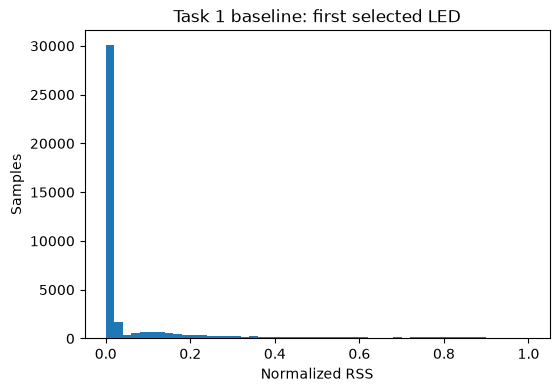

In [6]:
rss_scale = max(float(np.max(np.abs(X_train_raw))), 1e-8)
X_train = X_train_raw / rss_scale
X_val = X_val_raw / rss_scale

target_min_cm = y_train_cm.min(axis=0)
target_range_cm = np.maximum(y_train_cm.max(axis=0) - target_min_cm, 1e-8)
y_train = (y_train_cm - target_min_cm) / target_range_cm
y_val = (y_val_cm - target_min_cm) / target_range_cm

print("RSS scale:", rss_scale)
print("Target min cm:", target_min_cm)
print("Target range cm:", target_range_cm)

plt.figure(figsize=(6, 4))
plt.hist(X_train[:, 0], bins=50)
plt.xlabel("Normalized RSS")
plt.ylabel("Samples")
plt.title("Task 1 baseline: first selected LED")
plt.show()

## Naive baseline MLP

The network is deliberately small and conventional: `9 -> 32 -> 32 -> 2`, with ReLU hidden activations and a sigmoid output. It is a starter baseline and should be improved for your submission.

In [22]:
# You may tune these
lr = 1e-3
epochs = 25
batch_size = 512

In [26]:
from vlp_hackathon.improved_model import ImprovedMLP

model = BaselineMLP(input_features=X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.MSELoss()

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val)
print(model)

BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
    (5): Sigmoid()
  )
)


epoch=01 train_mse=0.083983 val_mse=0.057745
epoch=02 train_mse=0.029048 val_mse=0.010302
epoch=03 train_mse=0.008960 val_mse=0.007419
epoch=04 train_mse=0.007486 val_mse=0.006628
epoch=05 train_mse=0.006679 val_mse=0.005886
epoch=06 train_mse=0.005882 val_mse=0.005082
epoch=07 train_mse=0.004977 val_mse=0.004154
epoch=08 train_mse=0.003990 val_mse=0.003276
epoch=09 train_mse=0.003178 val_mse=0.002652
epoch=10 train_mse=0.002613 val_mse=0.002225
epoch=11 train_mse=0.002195 val_mse=0.001843
epoch=12 train_mse=0.001790 val_mse=0.001500
epoch=13 train_mse=0.001476 val_mse=0.001250
epoch=14 train_mse=0.001247 val_mse=0.001078
epoch=15 train_mse=0.001086 val_mse=0.000960
epoch=16 train_mse=0.000969 val_mse=0.000873
epoch=17 train_mse=0.000884 val_mse=0.000802
epoch=18 train_mse=0.000818 val_mse=0.000759
epoch=19 train_mse=0.000766 val_mse=0.000713
epoch=20 train_mse=0.000723 val_mse=0.000668
epoch=21 train_mse=0.000684 val_mse=0.000638
epoch=22 train_mse=0.000649 val_mse=0.000604
epoch=23 t

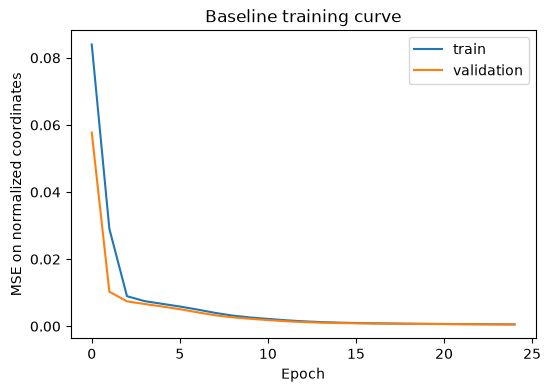

In [27]:
history = []
train_rng = np.random.default_rng(SEED)
for epoch in range(epochs):
    model.train()
    permutation = train_rng.permutation(len(X_train))
    running = 0.0
    for start in range(0, len(permutation), batch_size):
        idx = permutation[start:start + batch_size]
        xb = X_train_t[idx]
        yb = y_train_t[idx]
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += float(loss.item()) * len(idx)

    model.eval()
    with torch.no_grad():
        val_loss = float(loss_fn(model(X_val_t), y_val_t).item())
    history.append((running / len(X_train), val_loss))
    print(f"epoch={epoch + 1:02d} train_mse={history[-1][0]:.6f} val_mse={val_loss:.6f}")

history = np.asarray(history, dtype=np.float32)
plt.figure(figsize=(6, 4))
plt.plot(history[:, 0], label="train")
plt.plot(history[:, 1], label="validation")
plt.xlabel("Epoch")
plt.ylabel("MSE on normalized coordinates")
plt.legend()
plt.title("Baseline training curve")
plt.show()

Float validation mean error:   7.273 cm
Float validation median error: 5.898 cm
Float validation p95 error:    17.986 cm


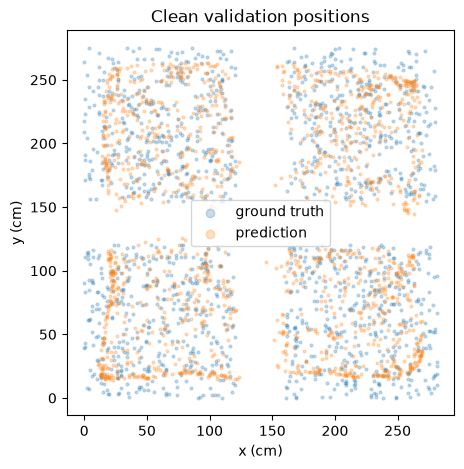

In [28]:
model.eval()
with torch.no_grad():
    float_norm = model(torch.from_numpy(X_val)).numpy()
float_pred_cm = target_min_cm + float_norm * target_range_cm
float_errors = euclidean_errors_cm(float_pred_cm, y_val_cm)

print(f"Float validation mean error:   {float_errors.mean():.3f} cm")
print(f"Float validation median error: {np.median(float_errors):.3f} cm")
print(f"Float validation p95 error:    {np.percentile(float_errors, 95):.3f} cm")

plt.figure(figsize=(5, 5))
n_show = min(1500, len(y_val_cm))
plt.scatter(y_val_cm[:n_show, 0], y_val_cm[:n_show, 1], s=4, alpha=0.25, label="ground truth")
plt.scatter(float_pred_cm[:n_show, 0], float_pred_cm[:n_show, 1], s=4, alpha=0.25, label="prediction")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.legend(markerscale=3)
plt.title("Clean validation positions")
plt.show()

## Save the trained model and export TFLite

The trained PyTorch state is saved first. A small helper is then run in a fresh Python process to export the model with LiteRT Torch. The output is a standard `.tflite` flatbuffer and is copied into the Pico firmware template.

In [11]:
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
torch.save(model.state_dict(), models_dir / "baseline_task1.pt")
np.savez(
    models_dir / "baseline_task1_scaling.npz",
    rss_scale=np.asarray(rss_scale, dtype=np.float32),
    target_min_cm=target_min_cm.astype(np.float32),
    target_range_cm=target_range_cm.astype(np.float32),
    train_loss=history,
    float_errors=float_errors.astype(np.float32),
)
print("Saved trained state and scaling constants")

Saved trained state and scaling constants


In [12]:
import subprocess
import sys

export_command = [
    sys.executable,
    str(ROOT / "scripts" / "export_litert_baseline.py"),
]

print("Running LiteRT export helper:")
print(" ".join(export_command))

subprocess.run(
    export_command,
    cwd=ROOT,
    check=True,
)

tflite_path = ROOT / "models" / "baseline_task1.tflite"
assert tflite_path.exists(), f"Export completed but {tflite_path} was not created."

print("TFLite bytes:", tflite_path.stat().st_size)

Running LiteRT export helper:
/home/lucan/projects/vlc_hackaton/.venv/bin/python /home/lucan/projects/vlc_hackaton/scripts/export_litert_baseline.py


I0000 00:00:1783510984.860756 2291926 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/lucan/projects/vlc_hackaton/.venv/lib/python3.12/site-packages/torchao/quantization/quant_api.py:1745: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.


(00:00) [START] LiteRT-Torch Convert
(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default
(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > 
ExportedProgram Run Decompositions
(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default (+00:00)
(00:00) [START] LiteRT-Torch Convert > Run FX Passes


/home/lucan/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:01) [START] LiteRT-Torch Convert > Run FX Passes > ExportedProgram Run 
Decompositions
(00:01) [ DONE] LiteRT-Torch Convert > Run FX Passes > ExportedProgram Run 
Decompositions (+00:00)
(00:01) [ DONE] LiteRT-Torch Convert > Run FX Passes (+00:00)
(00:01) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default
(00:01) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions


/home/lucan/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:01) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions
(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > 
ExportedProgram Run Decompositions (+00:00)
(00:01) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create 
MLIR Module
(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create 
MLIR Module (+00:00)
(00:01) [ DONE] LiteRT-Torch Convert > Lower to MLIR: serving_default (+00:00)
(00:01) [START] LiteRT-Torch Convert > Merge MLIR Modules
(00:01) [ DONE] LiteRT-Torch Convert > Merge MLIR Modules (+00:00)
(00:01) [START] LiteRT-Torch Convert > Run LiteRT Converter Passes
(00:01) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)
(00:01) [ DONE] LiteRT-Torch Convert (+00:01)
(00:00) [START] Write Model to Bytes
(00:00) [ DONE] Write Model to Byte

/home/lucan/projects/vlc_hackaton/.venv/lib/python3.12/site-packages/litert_torch/_convert/signature.py:52: FutureWarning: `treespec.children_specs` is deprecated. Use `treespec.child(index)` to access a single child, or `treespec.children()` to get all children.
  args_spec, kwargs_spec = spec.children_specs
/home/lucan/projects/vlc_hackaton/.venv/lib/python3.12/site-packages/litert_torch/_convert/signature.py:58: FutureWarning: `treespec.children_specs` is deprecated. Use `treespec.child(index)` to access a single child, or `treespec.children()` to get all children.
  kwargs_spec.children_specs, kwargs_spec.context
I0000 00:00:1783510991.410290 2291926 flatbuffer_export.cc:4346] Estimated count of arithmetic ops: 2946  ops, equivalently 1473  MACs


TFLite bytes: 8708


## Check the exported TFLite model

The same normalized validation vectors are sent through the exported flatbuffer using the LiteRT interpreter. The result should closely match the PyTorch model.

In [13]:
from ai_edge_litert.interpreter import Interpreter
tflite_bytes = tflite_path.read_bytes()
interpreter = Interpreter(model_content=tflite_bytes)
interpreter.allocate_tensors()
input_info = interpreter.get_input_details()[0]
output_info = interpreter.get_output_details()[0]

print("Input dtype:", input_info["dtype"], "shape:", input_info["shape"])
print("Output dtype:", output_info["dtype"], "shape:", output_info["shape"])

pred_norm = np.empty((len(X_val), 2), dtype=np.float32)
for i, row in enumerate(X_val):
    interpreter.set_tensor(input_info["index"], row[None, :].astype(input_info["dtype"]))
    interpreter.invoke()
    pred_norm[i] = interpreter.get_tensor(output_info["index"])[0]

tflite_pred_cm = target_min_cm + pred_norm * target_range_cm
tflite_errors = euclidean_errors_cm(tflite_pred_cm, y_val_cm)
print(f"TFLite validation mean error:   {tflite_errors.mean():.3f} cm")
print(f"TFLite validation median error: {np.median(tflite_errors):.3f} cm")
print(f"TFLite validation p95 error:    {np.percentile(tflite_errors, 95):.3f} cm")

Input dtype: <class 'numpy.float32'> shape: [1 9]
Output dtype: <class 'numpy.float32'> shape: [1 2]
TFLite validation mean error:   5.859 cm
TFLite validation median error: 4.704 cm
TFLite validation p95 error:    15.693 cm


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Export directly into the Pico firmware template

The final cell converts the exact `.tflite` flatbuffer to `model_data.cc`/`.h` and writes preprocessing and coordinate de-normalization constants. The firmware template accepts float32 or INT8 model I/O, so you can replace this simple float baseline with your own quantized model later.

In [14]:
firmware_dir = ROOT / "firmware" / "vlp_serial"
tflite_to_c_array(
    firmware_dir / "vlp_model.tflite",
    firmware_dir / "model_data.cc",
    firmware_dir / "model_data.h",
)

def c_float(value):
    text = f"{float(value):.9g}"
    if "." not in text and "e" not in text.lower():
        text += ".0"
    return text + "f"

(firmware_dir / "preprocess_data.h").write_text(
    "#pragma once\n\n"
    f"constexpr float kRssScale = {c_float(rss_scale)};\n",
    encoding="utf-8",
)
(firmware_dir / "target_scale_data.h").write_text(
    "#pragma once\n\n"
    f"constexpr float kTargetXMinCm = {c_float(target_min_cm[0])};\n"
    f"constexpr float kTargetYMinCm = {c_float(target_min_cm[1])};\n"
    f"constexpr float kTargetXRangeCm = {c_float(target_range_cm[0])};\n"
    f"constexpr float kTargetYRangeCm = {c_float(target_range_cm[1])};\n",
    encoding="utf-8",
)
print("Firmware model and headers updated in:", firmware_dir)

Firmware model and headers updated in: /home/lucan/projects/vlc_hackaton/firmware/vlp_serial
